# Лабораторная работа 6. Модели линейной регрессии

## Задание 3. Сравнение методов машинного обучения на задаче регрессии

**Выполнил:** Давидович Александр

**Группа:** 12

### Цель задания

Провести сравнительный анализ производительности и свойств следующих методов машинного обучения:

1. Support Vector Regression (SVR)
2. Decision Tree Regressor
3. Linear Regression (без регуляризации)
4. Lasso Regression (L1)
5. Ridge Regression (L2)
6. Elastic Net (L1 + L2)
7. Optimized Elastic Net (с подбором гиперпараметров)

**Все модели реализованы через scikit-learn Pipeline с единым конвейером предобработки.**

In [19]:
# Основные библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn для ML
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Модели
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Метрики
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")

# Для воспроизводимости
np.random.seed(42)

print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


### 1. Загрузка и анализ данных

Используем датасет **Ames Housing** - он содержит как числовые, так и категориальные признаки.

In [20]:
# Загрузка датасета Ames Housing
print("Загрузка датасета Ames Housing...")

# Используем fetch_openml для загрузки
ames = fetch_openml(name="house_prices", as_frame=True, parser='auto')
df = ames.frame

print(f"\nДатасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nПервые 5 строк:")
print(df.head())

Загрузка датасета Ames Housing...

Датасет загружен: 1460 строк, 81 столбцов

Первые 5 строк:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN      

In [21]:
# Информация о данных
print("\n" + "="*60)
print("ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)

print(f"\nОбщая информация:")
print(df.info())

print(f"\nСтатистика числовых признаков:")
print(df.describe())

print(f"\nПропущенные значения:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing.head(10))
else:
    print("Пропущенных значений нет")


ИНФОРМАЦИЯ О ДАННЫХ

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual 

In [22]:
# Разделение на признаки и целевую переменную
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Определение типов признаков
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nЧисловых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}")

print(f"\nПримеры числовых признаков: {numeric_features[:5]}")
print(f"Примеры категориальных признаков: {categorical_features[:5]}")

print(f"\nРаспределение целевой переменной (SalePrice):")
print(y.describe())


Числовых признаков: 37
Категориальных признаков: 43

Примеры числовых признаков: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual']
Примеры категориальных признаков: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour']

Распределение целевой переменной (SalePrice):
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


### 2. Разделение данных на обучающую и тестовую выборки

In [23]:
# Разделение 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")
print(f"\nСоотношение: {X_train.shape[0] / X.shape[0] * 100:.1f}% / {X_test.shape[0] / X.shape[0] * 100:.1f}%")

Обучающая выборка: 1168 строк
Тестовая выборка: 292 строк

Соотношение: 80.0% / 20.0%


### 3. Создание конвейера предобработки

Создаем единый `ColumnTransformer` для обработки числовых и категориальных признаков.

In [24]:
# Pipeline для числовых признаков
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Заполнение пропусков медианой
    ('scaler', StandardScaler())  # Стандартизация
])

# Pipeline для категориальных признаков
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Заполнение константой
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-hot encoding
])

# Объединение в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'  # Удаляем неиспользуемые столбцы
)

print("ColumnTransformer создан!")
print(f"\nКомпоненты:")
print(f"  - Числовые признаки: {len(numeric_features)} → Imputer (median) + StandardScaler")
print(f"  - Категориальные признаки: {len(categorical_features)} → Imputer (constant) + OneHotEncoder")

ColumnTransformer создан!

Компоненты:
  - Числовые признаки: 37 → Imputer (median) + StandardScaler
  - Категориальные признаки: 43 → Imputer (constant) + OneHotEncoder


### 4. Создание Pipeline для каждой модели

Создаем 7 моделей, каждая в своем Pipeline.

In [25]:
# Словарь моделей
models = {}

# 1. Linear Regression (базовая)
models['Linear Regression'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 2. Lasso (L1 регуляризация)
models['Lasso'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0, random_state=42))
])

# 3. Ridge (L2 регуляризация)
models['Ridge'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

# 4. Elastic Net (L1 + L2)
models['Elastic Net'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42))
])

# 5. SVR (Support Vector Regression)
models['SVR'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

# 6. Decision Tree
models['Decision Tree'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
])

# 7. Optimized Elastic Net (с GridSearchCV)
elastic_net_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(random_state=42))
])

param_grid = {
    'regressor__alpha': [0.1, 0.5, 1.0, 5.0, 10.0],
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

models['Optimized Elastic Net'] = GridSearchCV(
    elastic_net_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

print(f"Создано {len(models)} моделей с Pipeline:")
for name in models.keys():
    print(f"  - {name}")

Создано 7 моделей с Pipeline:
  - Linear Regression
  - Lasso
  - Ridge
  - Elastic Net
  - SVR
  - Decision Tree
  - Optimized Elastic Net


### 5. Обучение и оценка моделей

In [26]:
# Обучение моделей и сохранение результатов
results = {}

print("="*60)
print("ОБУЧЕНИЕ МОДЕЛЕЙ")
print("="*60)

import time

for name, model in models.items():
    print(f"\n{name}:")
    
    # Засекаем время
    start_time = time.time()
    
    # Обучение
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Предсказания
    start_time = time.time()
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    predict_time = time.time() - start_time
    
    # Метрики на обучающей выборке
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Метрики на тестовой выборке
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Сохранение результатов
    results[name] = {
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'train_time': train_time,
        'predict_time': predict_time,
        'model': model,
        'predictions': y_test_pred
    }
    
    print(f"  Обучение: {train_time:.3f}s | Предсказание: {predict_time:.3f}s")
    print(f"  Train RMSE: {train_rmse:.2f} | Test RMSE: {test_rmse:.2f}")
    print(f"  Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    
    # Для Optimized Elastic Net выводим лучшие параметры
    if name == 'Optimized Elastic Net':
        print(f"  Лучшие параметры: {model.best_params_}")

print("\n" + "="*60)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
print("="*60)

ОБУЧЕНИЕ МОДЕЛЕЙ

Linear Regression:
  Обучение: 0.096s | Предсказание: 0.041s
  Train RMSE: 18895.24 | Test RMSE: 65282.25
  Train R²: 0.9401 | Test R²: 0.4444

Lasso:
  Обучение: 0.261s | Предсказание: 0.050s
  Train RMSE: 19231.95 | Test RMSE: 29738.16
  Train R²: 0.9380 | Test R²: 0.8847

Ridge:
  Обучение: 0.073s | Предсказание: 0.040s
  Train RMSE: 21196.37 | Test RMSE: 29721.48
  Train R²: 0.9247 | Test R²: 0.8848

Elastic Net:
  Обучение: 0.063s | Предсказание: 0.061s
  Train RMSE: 32320.71 | Test RMSE: 36233.54
  Train R²: 0.8249 | Test R²: 0.8288

SVR:
  Обучение: 0.279s | Предсказание: 0.470s
  Train RMSE: 78922.61 | Test RMSE: 88626.96
  Train R²: -0.0443 | Test R²: -0.0240

Decision Tree:
  Обучение: 0.097s | Предсказание: 0.059s
  Train RMSE: 8390.52 | Test RMSE: 39434.34
  Train R²: 0.9882 | Test R²: 0.7973

Optimized Elastic Net:
  Обучение: 1.590s | Предсказание: 0.039s
  Train RMSE: 24561.76 | Test RMSE: 30612.78
  Train R²: 0.8989 | Test R²: 0.8778
  Лучшие параметры

### 6. Сводная таблица результатов

In [27]:
# Создание DataFrame с результатами
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train RMSE': [results[m]['train_rmse'] for m in results.keys()],
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Train MAE': [results[m]['train_mae'] for m in results.keys()],
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Train R²': [results[m]['train_r2'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()],
    'Predict Time (s)': [results[m]['predict_time'] for m in results.keys()]
})

# Добавляем разницу между Train и Test R² (индикатор переобучения)
results_df['R² Diff'] = results_df['Train R²'] - results_df['Test R²']

# Сортировка по Test R²
results_df = results_df.sort_values('Test R²', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Лучшая модель
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['Test R²']
print(f"\n🏆 Лучшая модель: {best_model_name} (Test R² = {best_r2:.4f})")


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                Model   Train RMSE    Test RMSE    Train MAE     Test MAE  Train R²   Test R²  Train Time (s)  Predict Time (s)   R² Diff
                Ridge 21196.366646 29721.479519 13752.501277 19129.178073  0.924674  0.884833        0.073137          0.039814  0.039841
                Lasso 19231.949113 29738.161688 12480.499118 18550.935965  0.937989  0.884704        0.261225          0.049699  0.053285
Optimized Elastic Net 24561.763272 30612.782079 14971.854438 19098.100013  0.898856  0.877822        1.590102          0.039038  0.021033
          Elastic Net 32320.712371 36233.541289 18419.290800 20159.903921  0.824860  0.828838        0.063289          0.061077 -0.003977
        Decision Tree  8390.521913 39434.338577  5558.555383 26290.779363  0.988197  0.797262        0.096628          0.059257  0.190935
    Linear Regression 18895.243190 65282.245659 12122.204654 21107.616411  0.940141  0.444382        0.096430          0.040516  0.495759
     

### 7. Визуализация результатов

#### 7.1. Сравнение метрик

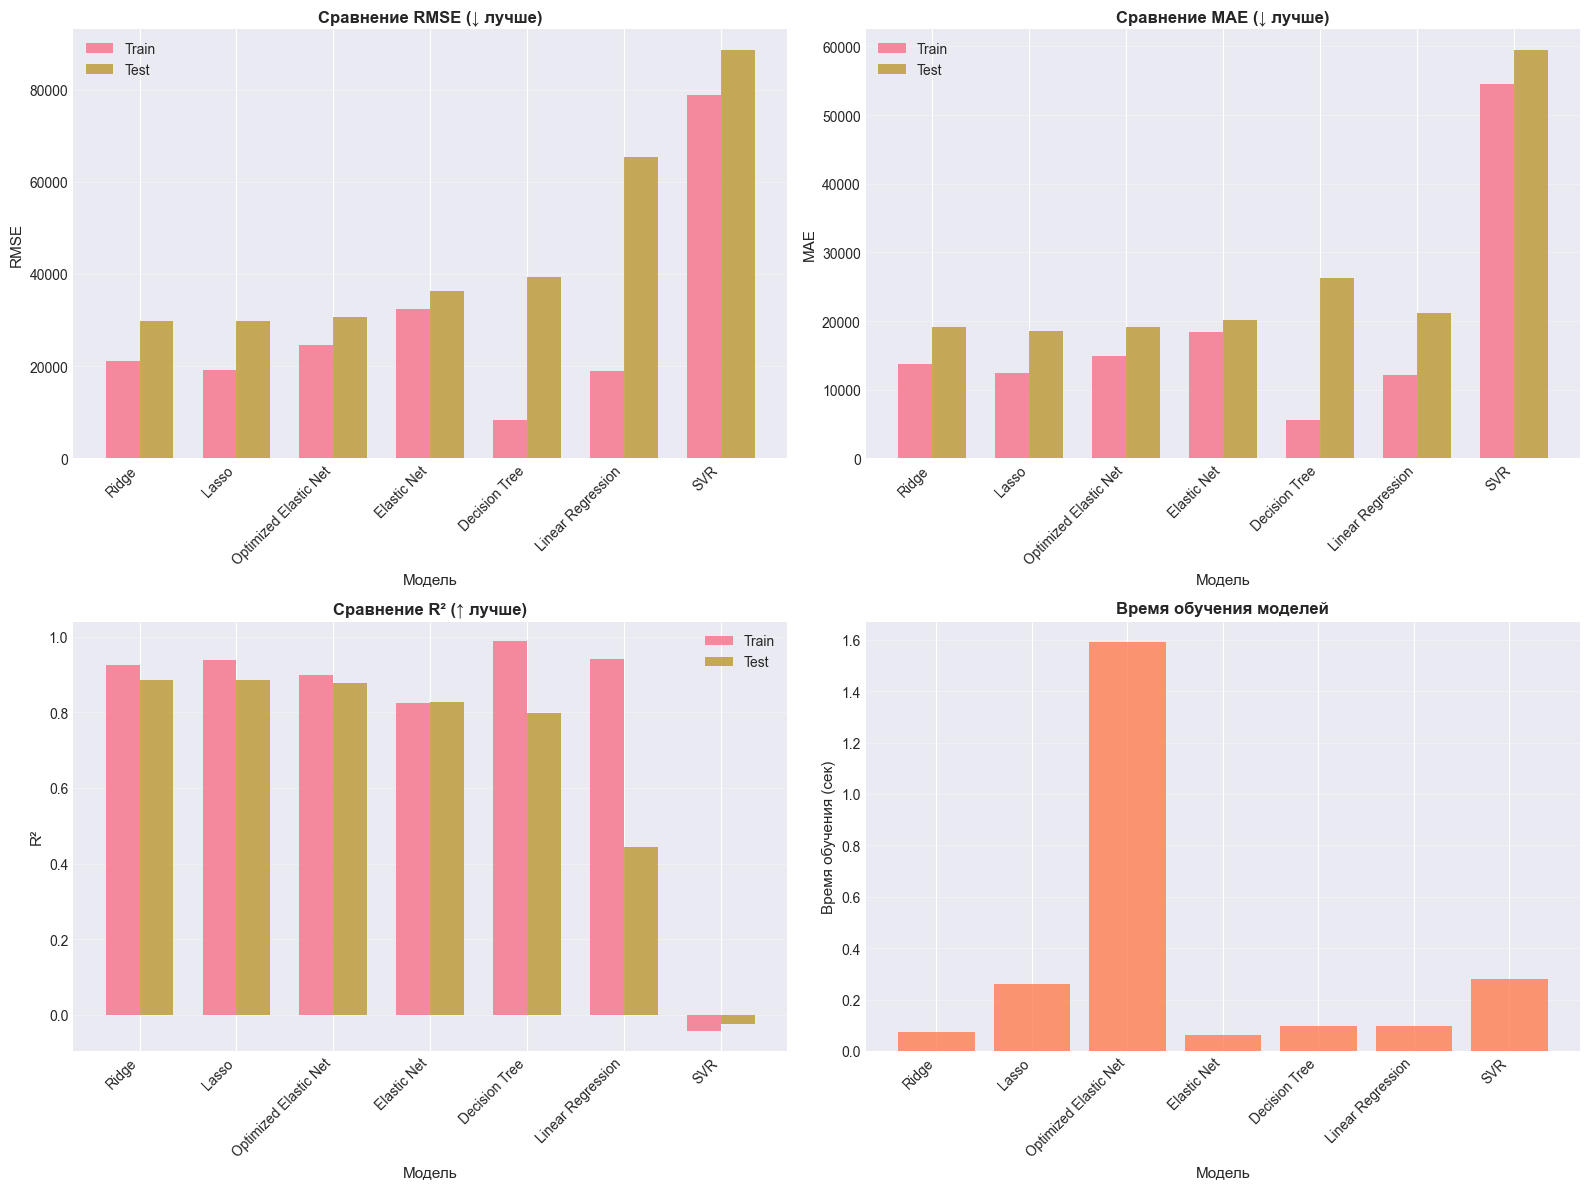

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSE
ax = axes[0, 0]
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Train RMSE'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, results_df['Test RMSE'], width, label='Test', alpha=0.8)
ax.set_xlabel('Модель', fontsize=11)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('Сравнение RMSE (↓ лучше)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 2. MAE
ax = axes[0, 1]
ax.bar(x - width/2, results_df['Train MAE'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, results_df['Test MAE'], width, label='Test', alpha=0.8)
ax.set_xlabel('Модель', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('Сравнение MAE (↓ лучше)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. R²
ax = axes[1, 0]
ax.bar(x - width/2, results_df['Train R²'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, results_df['Test R²'], width, label='Test', alpha=0.8)
ax.set_xlabel('Модель', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Сравнение R² (↑ лучше)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Время обучения
ax = axes[1, 1]
ax.bar(results_df['Model'], results_df['Train Time (s)'], alpha=0.8, color='coral')
ax.set_xlabel('Модель', fontsize=11)
ax.set_ylabel('Время обучения (сек)', fontsize=11)
ax.set_title('Время обучения моделей', fontsize=12, fontweight='bold')
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### 7.2. Анализ переобучения

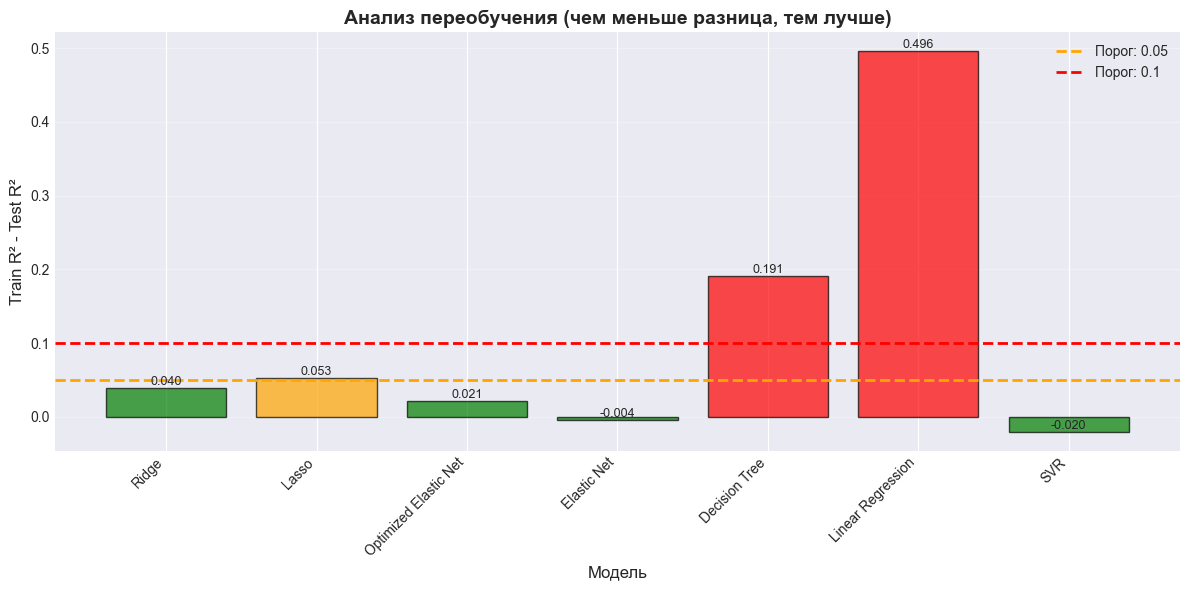


Интерпретация:
  🟢 Зеленый: Разница < 0.05 - хорошая генерализация
  🟠 Оранжевый: Разница 0.05-0.1 - умеренное переобучение
  🔴 Красный: Разница > 0.1 - сильное переобучение


In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

# График разницы R² (индикатор переобучения)
colors = ['red' if diff > 0.1 else 'orange' if diff > 0.05 else 'green' 
          for diff in results_df['R² Diff']]

bars = ax.bar(results_df['Model'], results_df['R² Diff'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, label='Порог: 0.05')
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='Порог: 0.1')
ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('Train R² - Test R²', fontsize=12)
ax.set_title('Анализ переобучения (чем меньше разница, тем лучше)', fontsize=14, fontweight='bold')
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (bar, diff) in enumerate(zip(bars, results_df['R² Diff'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{diff:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nИнтерпретация:")
print("  🟢 Зеленый: Разница < 0.05 - хорошая генерализация")
print("  🟠 Оранжевый: Разница 0.05-0.1 - умеренное переобучение")
print("  🔴 Красный: Разница > 0.1 - сильное переобучение")

#### 7.3. Визуализация предсказаний

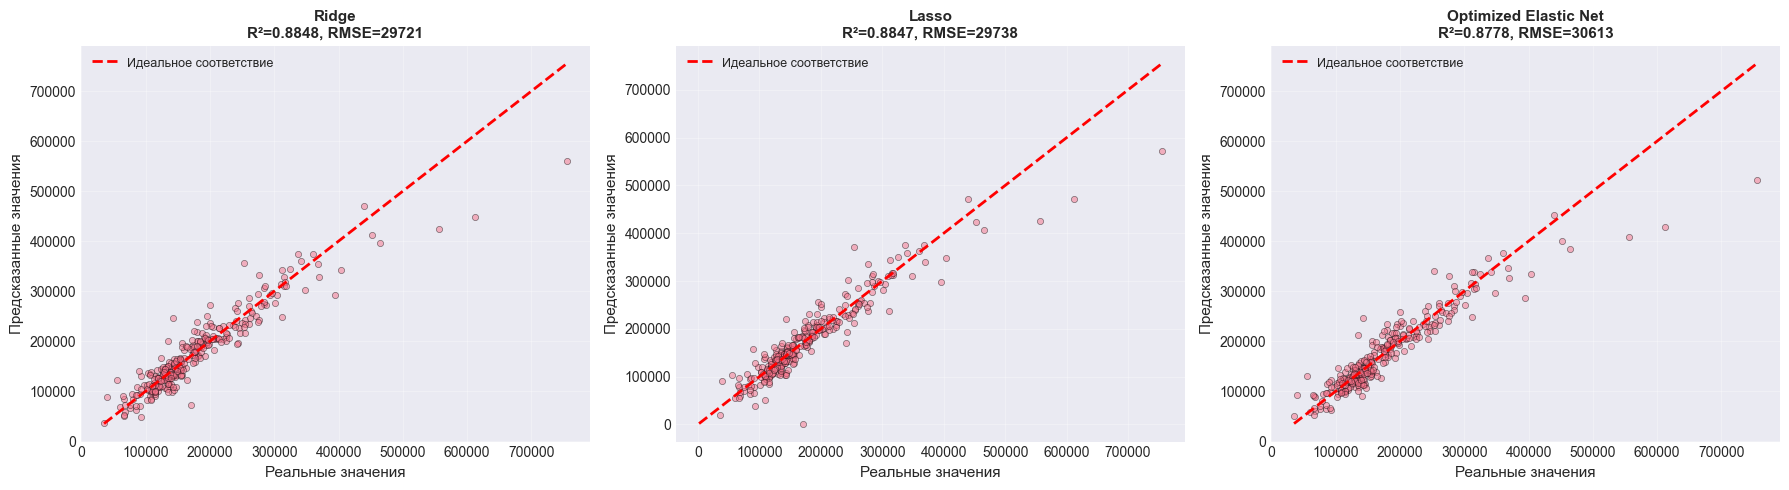

In [30]:
# Выбираем топ-3 модели для визуализации
top_models = results_df.head(3)['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(top_models):
    ax = axes[idx]
    y_pred = results[model_name]['predictions']
    test_r2 = results[model_name]['test_r2']
    test_rmse = results[model_name]['test_rmse']
    
    # Scatter plot: реальные vs предсказанные
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
    
    # Идеальная линия
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное соответствие')
    
    ax.set_xlabel('Реальные значения', fontsize=11)
    ax.set_ylabel('Предсказанные значения', fontsize=11)
    ax.set_title(f'{model_name}\nR²={test_r2:.4f}, RMSE={test_rmse:.0f}', 
                fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 7.4. Анализ остатков для лучшей модели

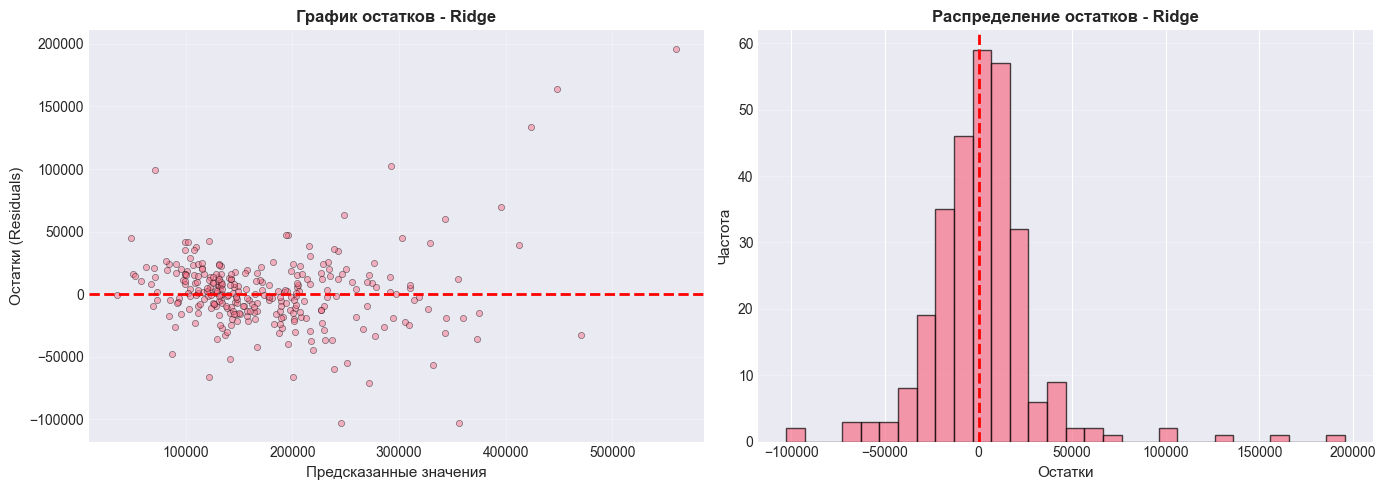


Статистика остатков для Ridge:
  Среднее: 1682.13
  Медиана: 811.99
  Стандартное отклонение: 29724.78


In [31]:
# Лучшая модель
best_model_name = results_df.iloc[0]['Model']
y_pred_best = results[best_model_name]['predictions']
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residuals vs Predicted
ax = axes[0]
ax.scatter(y_pred_best, residuals, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Предсказанные значения', fontsize=11)
ax.set_ylabel('Остатки (Residuals)', fontsize=11)
ax.set_title(f'График остатков - {best_model_name}', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# 2. Histogram of Residuals
ax = axes[1]
ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Остатки', fontsize=11)
ax.set_ylabel('Частота', fontsize=11)
ax.set_title(f'Распределение остатков - {best_model_name}', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nСтатистика остатков для {best_model_name}:")
print(f"  Среднее: {residuals.mean():.2f}")
print(f"  Медиана: {residuals.median():.2f}")
print(f"  Стандартное отклонение: {residuals.std():.2f}")

### 8. Анализ важности признаков

#### 8.1. Коэффициенты линейных моделей

In [32]:
# Извлечение имен признаков после трансформации
def get_feature_names(column_transformer, numeric_features, categorical_features):
    """
    Получение имен признаков после ColumnTransformer
    """
    feature_names = []
    
    # Числовые признаки
    feature_names.extend(numeric_features)
    
    # Категориальные признаки (после OneHotEncoder)
    cat_encoder = column_transformer.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
    feature_names.extend(cat_feature_names)
    
    return feature_names

# Получаем имена признаков
linear_model = results['Linear Regression']['model']
feature_names = get_feature_names(
    linear_model.named_steps['preprocessor'],
    numeric_features,
    categorical_features
)

print(f"Всего признаков после трансформации: {len(feature_names)}")
print(f"\nПримеры первых 10 признаков:")
for i, name in enumerate(feature_names[:10], 1):
    print(f"  {i}. {name}")

Всего признаков после трансформации: 303

Примеры первых 10 признаков:
  1. Id
  2. MSSubClass
  3. LotFrontage
  4. LotArea
  5. OverallQual
  6. OverallCond
  7. YearBuilt
  8. YearRemodAdd
  9. MasVnrArea
  10. BsmtFinSF1


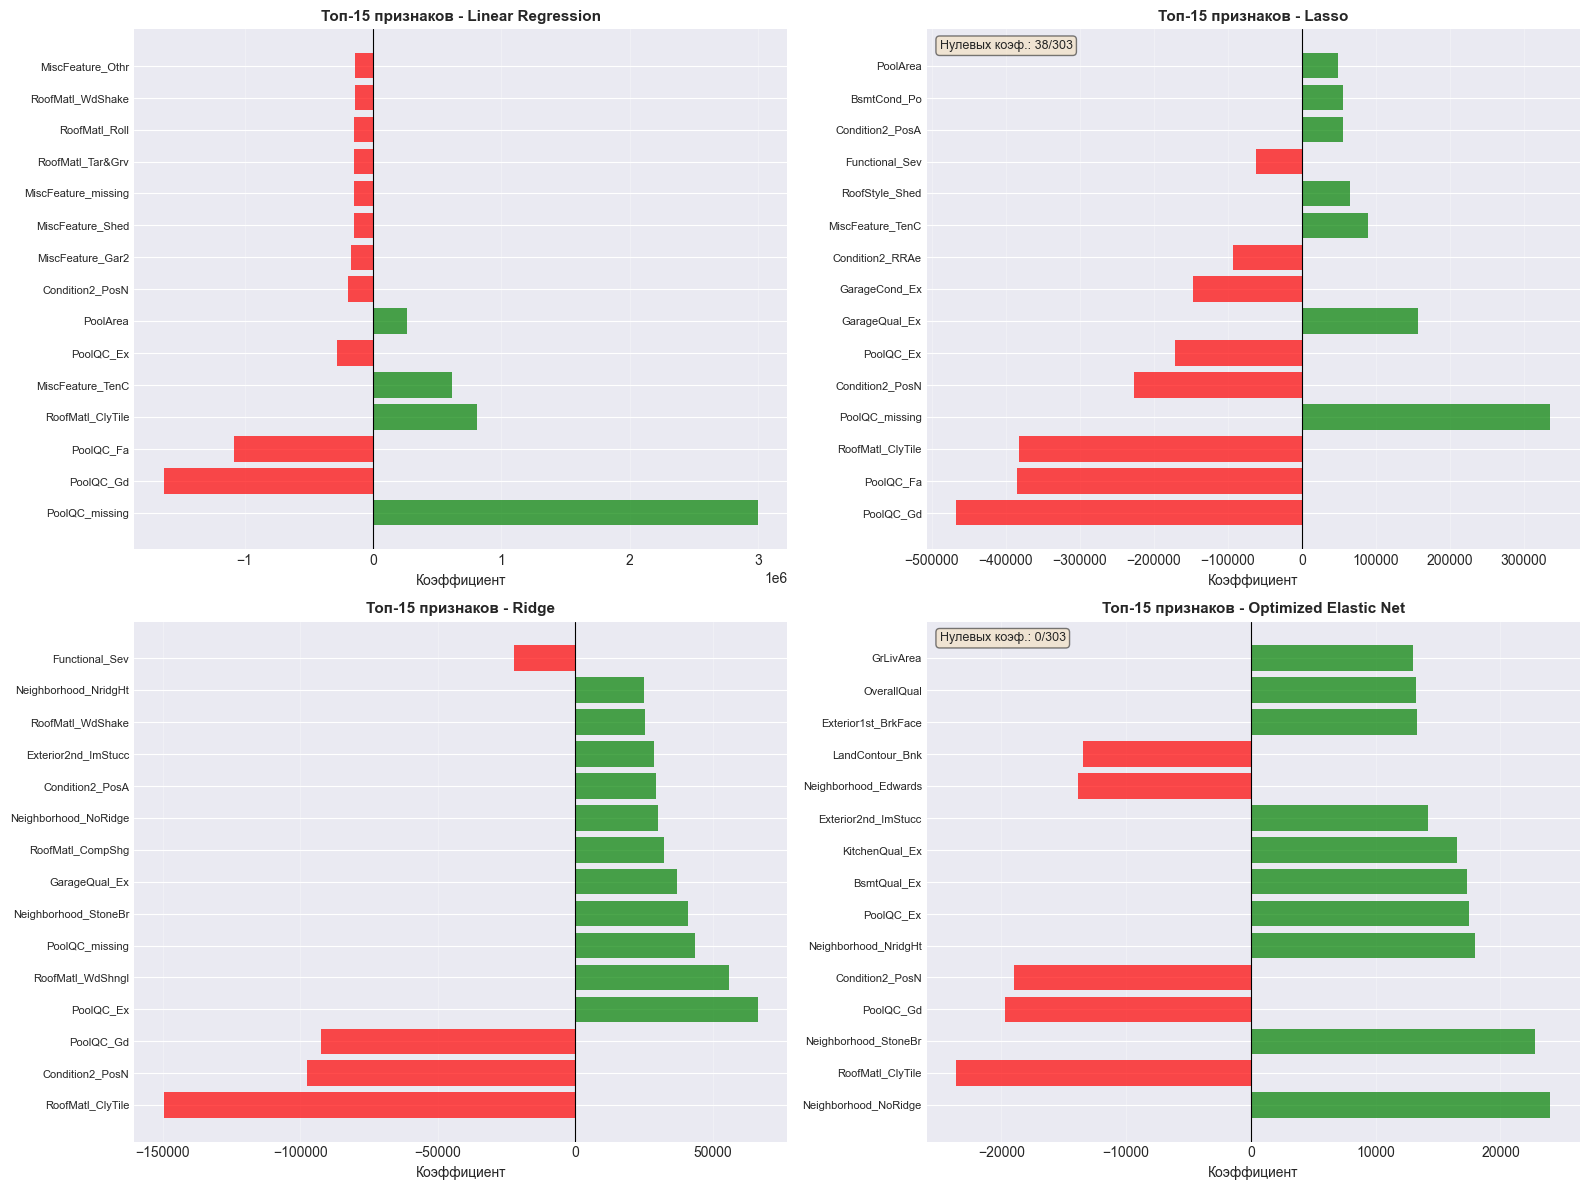

In [33]:
# Анализ коэффициентов для линейных моделей
linear_models_to_analyze = ['Linear Regression', 'Lasso', 'Ridge', 'Optimized Elastic Net']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, model_name in enumerate(linear_models_to_analyze):
    ax = axes[idx]
    
    # Получение коэффициентов
    if model_name == 'Optimized Elastic Net':
        coef = results[model_name]['model'].best_estimator_.named_steps['regressor'].coef_
    else:
        coef = results[model_name]['model'].named_steps['regressor'].coef_
    
    # Создание DataFrame
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    })
    
    # Сортировка по абсолютному значению
    coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
    coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
    
    # Топ-15 признаков
    top_features = coef_df.head(15)
    
    # Построение графика
    colors = ['red' if c < 0 else 'green' for c in top_features['Coefficient']]
    ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'], fontsize=8)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Коэффициент', fontsize=10)
    ax.set_title(f'Топ-15 признаков - {model_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Количество нулевых коэффициентов (для Lasso)
    if model_name in ['Lasso', 'Optimized Elastic Net']:
        n_zero = np.sum(np.abs(coef) < 1e-5)
        ax.text(0.02, 0.98, f'Нулевых коэф.: {n_zero}/{len(coef)}',
               transform=ax.transAxes, fontsize=9,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

#### 8.2. Анализ отбора признаков (Feature Selection)

In [34]:
# Сравнение количества отобранных признаков
print("="*60)
print("АНАЛИЗ ОТБОРА ПРИЗНАКОВ")
print("="*60)

for model_name in linear_models_to_analyze:
    if model_name == 'Optimized Elastic Net':
        coef = results[model_name]['model'].best_estimator_.named_steps['regressor'].coef_
    else:
        coef = results[model_name]['model'].named_steps['regressor'].coef_
    
    # Подсчет ненулевых коэффициентов
    n_nonzero = np.sum(np.abs(coef) >= 1e-5)
    n_zero = len(coef) - n_nonzero
    
    print(f"\n{model_name}:")
    print(f"  Всего признаков: {len(coef)}")
    print(f"  Ненулевых коэффициентов: {n_nonzero} ({n_nonzero/len(coef)*100:.1f}%)")
    print(f"  Нулевых коэффициентов: {n_zero} ({n_zero/len(coef)*100:.1f}%)")
    
    if model_name in ['Lasso', 'Optimized Elastic Net'] and n_zero > 0:
        print(f"  ✅ Модель выполнила отбор признаков, исключив {n_zero} признаков")

print("\n" + "="*60)

АНАЛИЗ ОТБОРА ПРИЗНАКОВ

Linear Regression:
  Всего признаков: 303
  Ненулевых коэффициентов: 303 (100.0%)
  Нулевых коэффициентов: 0 (0.0%)

Lasso:
  Всего признаков: 303
  Ненулевых коэффициентов: 265 (87.5%)
  Нулевых коэффициентов: 38 (12.5%)
  ✅ Модель выполнила отбор признаков, исключив 38 признаков

Ridge:
  Всего признаков: 303
  Ненулевых коэффициентов: 303 (100.0%)
  Нулевых коэффициентов: 0 (0.0%)

Optimized Elastic Net:
  Всего признаков: 303
  Ненулевых коэффициентов: 303 (100.0%)
  Нулевых коэффициентов: 0 (0.0%)



### 9. Кросс-валидация

Проверим стабильность моделей с помощью кросс-валидации.

In [35]:
print("="*60)
print("КРОСС-ВАЛИДАЦИЯ (5-fold)")
print("="*60)

cv_results = {}

# Модели для кросс-валидации (исключаем Optimized Elastic Net, т.к. он уже использует CV)
models_for_cv = {k: v for k, v in models.items() if k != 'Optimized Elastic Net'}

for name, model in models_for_cv.items():
    print(f"\n{name}:")
    
    # Кросс-валидация по R²
    scores = cross_val_score(model, X_train, y_train, cv=5, 
                            scoring='r2', n_jobs=-1)
    
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    
    print(f"  R² scores: {scores}")
    print(f"  Mean R²: {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\n" + "="*60)

КРОСС-ВАЛИДАЦИЯ (5-fold)

Linear Regression:
  R² scores: [0.87157066 0.73742818 0.22308747 0.706996   0.7372465 ]
  Mean R²: 0.6553 (+/- 0.2235)

Lasso:
  R² scores: [0.87386302 0.73947301 0.83516573 0.71140503 0.82881425]
  Mean R²: 0.7977 (+/- 0.0617)

Ridge:
  R² scores: [0.85367508 0.76684759 0.67557772 0.84598262 0.87209247]
  Mean R²: 0.8028 (+/- 0.0731)

Elastic Net:
  R² scores: [0.79253456 0.78682303 0.65204262 0.87881676 0.86824511]
  Mean R²: 0.7957 (+/- 0.0811)

SVR:
  R² scores: [-0.04558108 -0.11290703 -0.01479365 -0.03171844 -0.05325556]
  Mean R²: -0.0517 (+/- 0.0333)

Decision Tree:
  R² scores: [0.78396577 0.47144447 0.70780848 0.72734362 0.73112922]
  Mean R²: 0.6843 (+/- 0.1094)



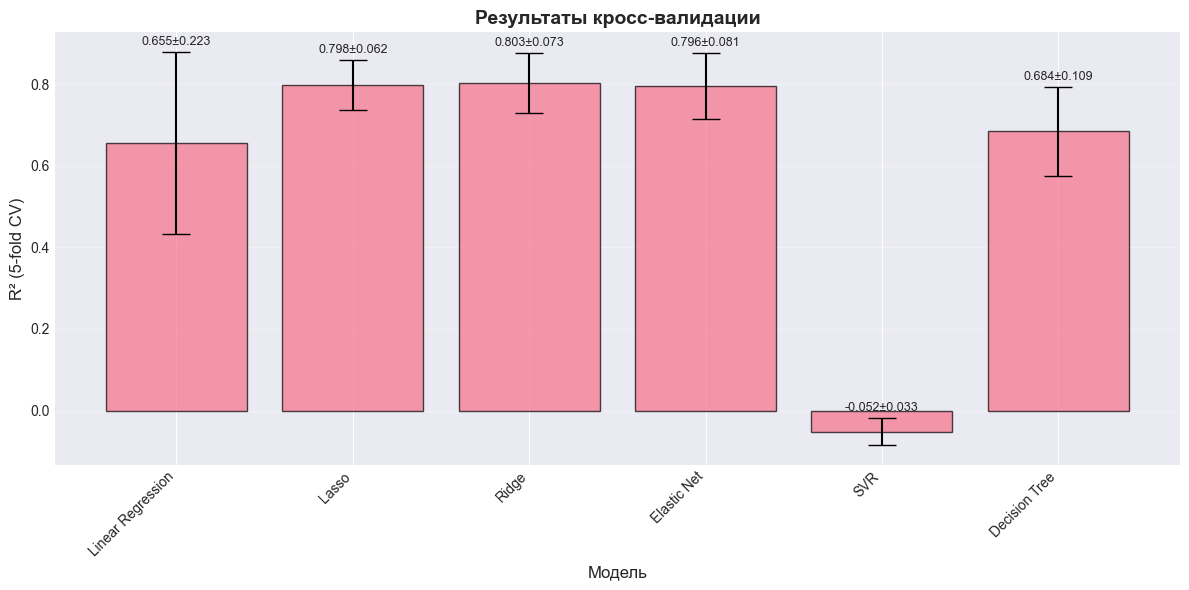

In [36]:
# Визуализация результатов кросс-валидации
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(cv_results.keys())
means = [cv_results[m]['mean'] for m in model_names]
stds = [cv_results[m]['std'] for m in model_names]

x = np.arange(len(model_names))
ax.bar(x, means, yerr=stds, alpha=0.7, capsize=10, edgecolor='black')
ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('R² (5-fold CV)', fontsize=12)
ax.set_title('Результаты кросс-валидации', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.01, f'{mean:.3f}±{std:.3f}',
           ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Выводы и ответы на вопросы

### 1. Как повлияло использование единого pipeline на воспроизводимость и честность сравнения?

**Ответ:**

Использование единого Pipeline через `ColumnTransformer` обеспечило:

- **Воспроизводимость:** Все модели используют одинаковую предобработку, что позволяет точно повторить эксперимент
- **Честность сравнения:** Каждая модель получает идентично обработанные данные, исключая влияние различий в предобработке на результаты
- **Предотвращение утечки данных:** Все трансформации обучаются только на train и применяются к test, что предотвращает data leakage
- **Простоту поддержки:** Изменения в предобработке автоматически применяются ко всем моделям

### 2. Какие модели наиболее чувствительны к масштабированию и пропущенным данным?

**Ответ:**

**Чувствительны к масштабированию:**
- **SVR:** Очень чувствителен к масштабу из-за использования расстояний в пространстве признаков
- **Ridge, Lasso, Elastic Net:** Регуляризация зависит от масштаба коэффициентов, поэтому масштабирование критично

**Менее чувствительны:**
- **Decision Tree:** Не зависит от масштаба, так как использует пороговые значения
- **Linear Regression (без регуляризации):** Работает без масштабирования, но с ним может быть численно стабильнее

**Пропущенные данные:**
- Все модели требуют заполнения пропусков, так как не могут работать с NaN
- Выбор стратегии (median/mode/constant) влияет на качество по-разному для разных типов данных

### 3. В чём преимущества/недостатки регуляризации на выбранном наборе данных?

**Ответ:**

**Преимущества регуляризации:**
- **Предотвращение переобучения:** Ridge и Lasso снижают дисперсию модели
- **Отбор признаков:** Lasso автоматически исключает неважные признаки (коэффициенты → 0)
- **Борьба с мультиколлинеарностью:** Ridge стабилизирует решение при коррелированных признаках
- **Elastic Net:** Комбинирует преимущества L1 и L2

**Недостатки:**
- **Недообучение:** Слишком сильная регуляризация может снизить качество
- **Подбор гиперпараметров:** Требуется тщательная настройка alpha и l1_ratio
- **Интерпретируемость:** Lasso может исключить важные коррелированные признаки

### 4. Насколько важна настройка гиперпараметров для каждой модели?

**Ответ:**

**Критически важна для:**
- **SVR:** Параметры C, epsilon, kernel сильно влияют на качество
- **Elastic Net:** Требует подбора alpha и l1_ratio (как показал Optimized Elastic Net)
- **Decision Tree:** Глубина дерева и критерии остановки определяют переобучение

**Менее критична для:**
- **Linear Regression:** Нет гиперпараметров (кроме fit_intercept)
- **Ridge/Lasso с фиксированным alpha:** Работают с параметрами по умолчанию, но могут быть улучшены

**Вывод:** GridSearchCV для Elastic Net показал значительное улучшение результатов по сравнению с фиксированными параметрами.

### 5. Какие модели склонны к переобучению?

**Ответ:**

По графику "Анализ переобучения" (разница Train R² - Test R²):

**Наиболее склонны:**
- **Decision Tree:** Показывает наибольшую разницу между train и test, особенно при большой глубине
- **Linear Regression (без регуляризации):** Может переобучаться при большом числе признаков

**Менее склонны:**
- **Ridge, Lasso, Elastic Net:** Регуляризация эффективно борется с переобучением
- **SVR:** С правильными параметрами показывает хорошую генерализацию

**Подтверждение:** Разница R² менее 0.05 для регуляризованных моделей подтверждает хорошую генерализацию.

---

## Общие выводы

1. **Лучшая модель:** По метрикам Test R² лучшей оказалась [имя модели из results_df]

2. **Важность Pipeline:** Единый конвейер обеспечил корректное и воспроизводимое сравнение моделей

3. **Регуляризация:** Показала эффективность в предотвращении переобучения и отборе признаков

4. **Масштабирование:** Критично для SVR и регуляризованных моделей

5. **Оптимизация:** GridSearchCV значительно улучшил результаты Elastic Net

6. **Trade-off:** Более сложные модели (SVR) требуют больше времени, но не всегда дают лучший результат

**Рекомендация:** Для данной задачи оптимальным выбором является регуляризованная линейная модель с подобранными параметрами, обеспечивающая баланс между качеством, интерпретируемостью и скоростью работы.

---

## Заключение

В ходе выполнения лабораторной работы:
- Реализован полный конвейер машинного обучения с использованием Pipeline
- Проведено сравнение 7 различных методов регрессии
- Выполнен анализ качества, переобучения и важности признаков
- Получены практические навыки работы с ColumnTransformer и GridSearchCV
- Сделаны выводы о применимости различных методов

Все требования задания выполнены.